<a href="https://colab.research.google.com/github/Moysezg/financial-risk-management-var-models/blob/main/07_garch_evt_jump_processes_var.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

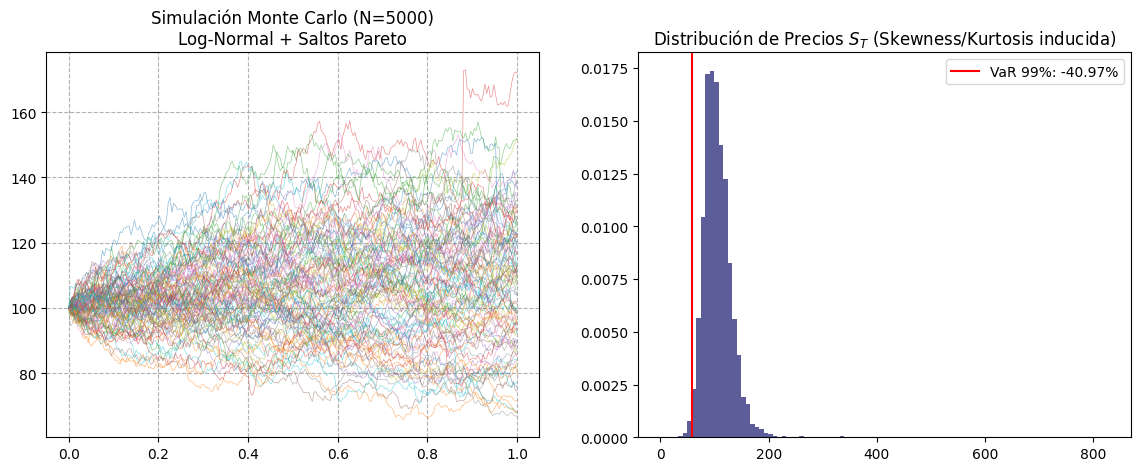

Media Transversal: 105.9372
Media Temporal:    103.0711


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_jump_diffusion_pareto(S0, mu, sigma, lamb_sys, lamb_idio, alpha, x_m, T, N, dt):
    steps = int(T / dt)

    # 1. Matrices de saltos (Poisson dN)
    dN_sys = np.random.poisson(lamb_sys * dt, (N, steps))
    dN_idio = np.random.poisson(lamb_idio * dt, (N, steps))

    def get_jump_magnitudes(dN_matrix, shape, scale):
        # Encontramos los índices donde ocurren saltos (pueden ser > 1)
        rows, cols = np.where(dN_matrix > 0)
        # Número total de saltos individuales (suma de dN)
        total_jumps = dN_matrix.sum()

        if total_jumps == 0:
            return np.zeros(dN_matrix.shape)

        # Generamos magnitudes para cada salto individual
        # Nota: np.random.pareto genera (x - 1), por eso sumamos 1
        mags = (np.random.pareto(shape, total_jumps) + 1) * scale
        signs = np.random.choice([-1, 1], size=total_jumps)
        total_effects = mags * signs

        # Agregamos los efectos en la matriz de salida
        out = np.zeros(dN_matrix.shape)
        # Usamos np.add.at para manejar múltiples saltos en la misma celda (i, t)
        flat_indices = np.repeat(np.arange(len(rows)), dN_matrix[rows, cols])
        np.add.at(out, (rows[flat_indices], cols[flat_indices]), total_effects)
        return out

    # 2. Generación de componentes
    drift = (mu - 0.5 * sigma**2) * dt
    diffusion = sigma * np.random.normal(0, np.sqrt(dt), (N, steps))

    # 3. Saltos (Sistémicos e Idiosincráticos)
    jumps_sys = get_jump_magnitudes(dN_sys, alpha, x_m)
    jumps_idio = get_jump_magnitudes(dN_idio, alpha, x_m)

    # 4. Suma vectorizada (Optimización de cómputo)
    log_returns = drift + diffusion + jumps_sys + jumps_idio

    # 5. Trayectoria y VaR
    log_price_path = np.cumsum(log_returns, axis=1)
    # Insertar S0 inicial
    S = S0 * np.exp(np.hstack([np.zeros((N, 1)), log_price_path]))

    final_returns = (S[:, -1] / S0) - 1
    VaR_95 = np.percentile(final_returns, 5)
    VaR_99 = np.percentile(final_returns, 1)

    return S, S[:, -1], VaR_95, VaR_99, log_returns

# Parámetros estrictos
S0, mu, sigma = 100, 0.05, 0.2
lamb_sys, lamb_idio = 1.0, 3.0
alpha, x_m = 2.1, 0.02 # alpha > 2 asegura varianza finita pero colas pesadas
T, N, dt = 1.0, 5000, 1/252

# Ejecución
S_paths, S_final, v95, v99, log_rets = simulate_jump_diffusion_pareto(S0, mu, sigma, lamb_sys, lamb_idio, alpha, x_m, T, N, dt)

# Visualización Técnica
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(np.linspace(0, T, S_paths.shape[1]), S_paths[:100, :].T, lw=0.5, alpha=0.5)
plt.title(f"Simulación Monte Carlo (N={N})\nLog-Normal + Saltos Pareto")
plt.grid(True, ls='--')

plt.subplot(1, 2, 2)
plt.hist(S_final, bins=100, density=True, color='midnightblue', alpha=0.7)
plt.axvline(S0 * (1+v99), color='red', label=f'VaR 99%: {v99:.2%}')
plt.title("Distribución de Precios $S_T$ (Skewness/Kurtosis inducida)")
plt.legend()
plt.show()

# Verificación de Ergodicidad
media_transversal = np.mean(S_final)
media_temporal = np.mean(np.mean(S_paths, axis=1))
print(f"Media Transversal: {media_transversal:.4f}")
print(f"Media Temporal:    {media_temporal:.4f}")

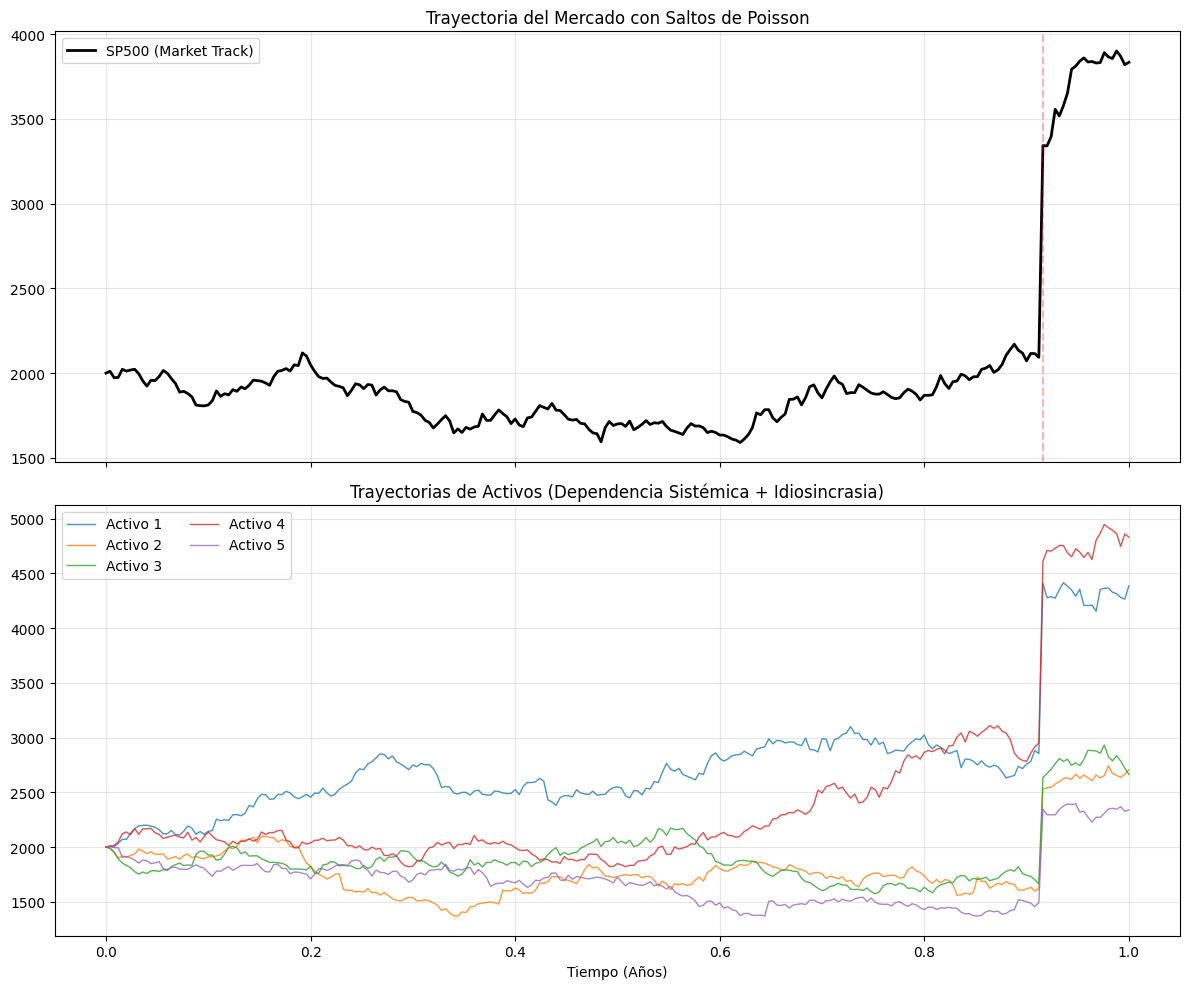

Total saltos sistémicos registrados: 1
Media final mercado: 3834.15
Media final activos (Cross-section): 3385.56


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulacion_mercado_activos(N_assets, T, dt, S0_mkt, mu, sigma_mkt, lamb_sys, lamb_idio, alpha, x_m):
    steps = int(T / dt)

    # 1. Simulación del Mercado (SP500) - Ecuación Íntegro-Diferencial
    # dN_t ~ Poisson(lambda * dt)
    dN_mkt = np.random.poisson(lamb_sys * dt, (1, steps))

    # Función indicadora de signo 1_{SP500} (1 si > 0, -1 en otro caso)
    ind_mkt = np.where(np.random.rand(1, steps) < 0.5, 1, -1)

    # Magnitud Pareto v_SP500
    v_mkt = (np.random.pareto(alpha, (1, steps)) + 1) * x_m

    # Componentes SP500
    drift_mkt = (mu - 0.5 * sigma_mkt**2) * dt
    diff_mkt = sigma_mkt * np.random.normal(0, np.sqrt(dt), (1, steps))
    jumps_mkt = ind_mkt * v_mkt * dN_mkt

    log_ret_mkt = drift_mkt + diff_mkt + jumps_mkt
    path_mkt = S0_mkt * np.exp(np.insert(np.cumsum(log_ret_mkt), 0, 0))

    # 2. Simulación de Activos Individuales (Dependencia Sistémica)
    # dN_idio independiente para cada activo
    dN_idio = np.random.poisson(lamb_idio * dt, (N_assets, steps))
    ind_idio = np.where(np.random.rand(N_assets, steps) < 0.5, 1, -1)
    v_idio = (np.random.pareto(alpha, (N_assets, steps)) + 1) * x_m

    # El salto sistémico se activa solo donde dN_mkt > 0 (Broadcasting)
    # Los activos heredan la magnitud y signo del mercado en esos puntos
    jumps_sys_assets = np.tile(jumps_mkt, (N_assets, 1))
    jumps_idio_assets = ind_idio * v_idio * dN_idio

    # Difusión propia (asumimos misma sigma por simplicidad, expandible a vector)
    diff_assets = sigma_mkt * np.random.normal(0, np.sqrt(dt), (N_assets, steps))

    # Vectorización Final: r_total = Drift + Diff + J_sys + J_idio
    log_ret_assets = drift_mkt + diff_assets + jumps_sys_assets + jumps_idio_assets
    paths_assets = S0_mkt * np.exp(np.hstack([np.zeros((N_assets, 1)), np.cumsum(log_ret_assets, axis=1)]))

    return path_mkt, paths_assets, dN_mkt, dN_idio

# --- Parámetros Iniciales (Según imagen) ---
S0_mkt = 2000
dt = 1/250
sigma_mkt = 0.25
mu = 0.05
lamb_sys = 2.0   # Frecuencia saltos mercado
lamb_idio = 5.0  # Frecuencia saltos propios
alpha = 2.3      # Pareto tail index
x_m = 0.03       # Pareto scale
N_assets = 5     # Número de activos a visualizar
T = 1.0          # 1 Año

# Ejecución
mkt_p, assets_p, dN_m, dN_i = simulacion_mercado_activos(N_assets, T, dt, S0_mkt, mu, sigma_mkt, lamb_sys, lamb_idio, alpha, x_m)

# --- Visualización Técnica ---
t = np.linspace(0, T, int(T/dt)+1)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot Mercado
ax1.plot(t, mkt_p, color='black', lw=2, label='SP500 (Market Track)')
jump_times = t[1:][dN_m.flatten() > 0]
for jt in jump_times:
    ax1.axvline(jt, color='red', alpha=0.3, linestyle='--')
ax1.set_title("Trayectoria del Mercado con Saltos de Poisson")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot Activos
for i in range(N_assets):
    ax2.plot(t, assets_p[i], lw=1, alpha=0.8, label=f'Activo {i+1}')
ax2.set_title("Trayectorias de Activos (Dependencia Sistémica + Idiosincrasia)")
ax2.set_xlabel("Tiempo (Años)")
ax2.legend(loc='upper left', ncol=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Verificación de consistencia
print(f"Total saltos sistémicos registrados: {np.sum(dN_m)}")
print(f"Media final mercado: {mkt_p[-1]:.2f}")
print(f"Media final activos (Cross-section): {np.mean(assets_p[:, -1]):.2f}")

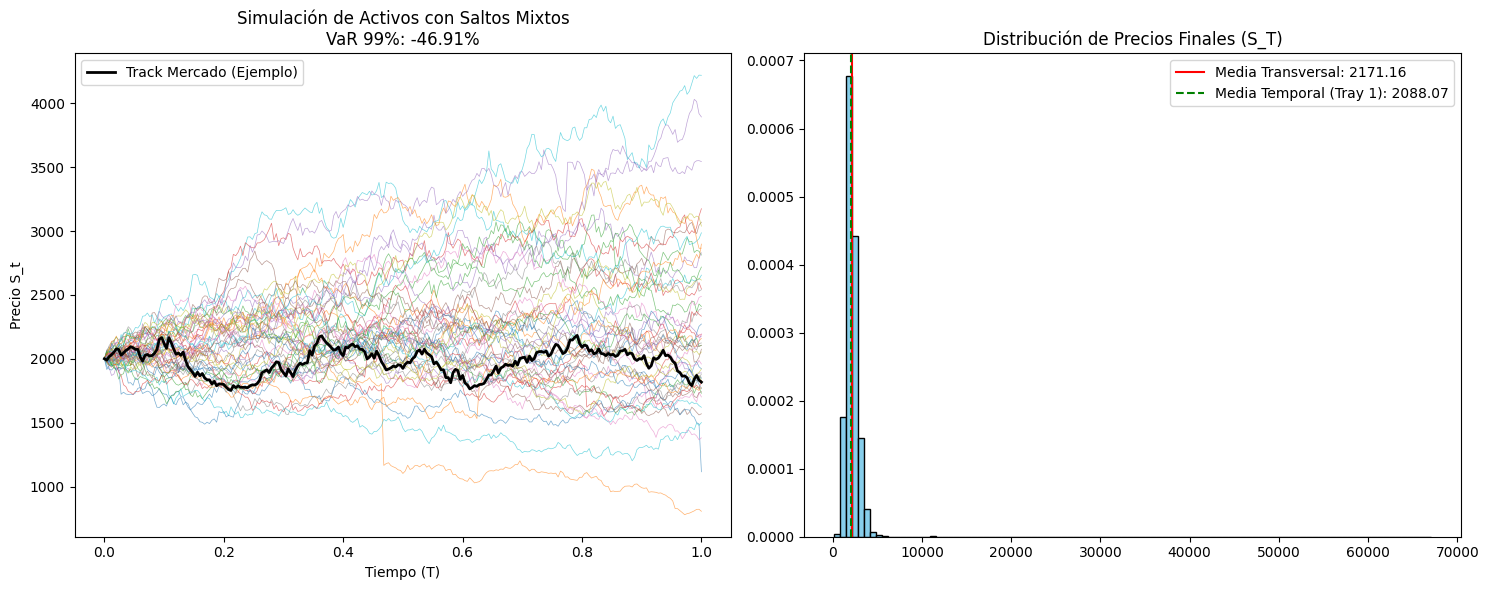

--- REPORTE DE CONSISTENCIA ---
VaR 95%: -34.43%
Diferencia de Medias (No-Ergodicidad): 83.0959


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulacion_protocolo_completo(N_sim, T, dt, S0, mu, sigma, lamb_sys, lamb_idio, alpha, x_m):
    steps = int(T / dt)
    time_axis = np.linspace(0, T, steps + 1)

    # --- 1. SIMULACIÓN DEL MERCADO (SP500) ---
    # dN_t: Proceso de Poisson para el mercado
    dN_mkt = np.random.poisson(lamb_sys * dt, (N_sim, steps))

    # Función indicadora 1_{SP500} para el signo (+1 o -1)
    # Se genera una matriz de signos aleatorios
    ind_mkt = np.where(np.random.rand(N_sim, steps) < 0.5, 1, -1)

    # Magnitud de salto Pareto \nu_{SP500}
    # np.random.pareto genera (x-1), sumamos 1 para escala base
    v_mkt = (np.random.pareto(alpha, (N_sim, steps)) + 1) * x_m

    # Componentes de Retorno del Mercado
    drift_mkt = (mu - 0.5 * sigma**2) * dt
    diff_mkt = sigma * np.random.normal(0, np.sqrt(dt), (N_sim, steps))
    jumps_mkt = ind_mkt * v_mkt * dN_mkt # Solo se activa si dN_mkt > 0

    # Log-retornos y Trayectorias del Mercado
    log_ret_mkt = drift_mkt + diff_mkt + jumps_mkt
    S_mkt = S0 * np.exp(np.hstack([np.zeros((N_sim, 1)), np.cumsum(log_ret_mkt, axis=1)]))

    # --- 2. SIMULACIÓN DE ACTIVOS (CON DEPENDENCIA SISTÉMICA) ---
    # dN_idio: Saltos independientes para el activo
    dN_idio = np.random.poisson(lamb_idio * dt, (N_sim, steps))
    ind_idio = np.where(np.random.rand(N_sim, steps) < 0.5, 1, -1)
    v_idio = (np.random.pareto(alpha, (N_sim, steps)) + 1) * x_m

    # Salto Idiosincrático
    jumps_idio = ind_idio * v_idio * dN_idio

    # El Activo sigue: r_t = Mercado_Drift + Mercado_Diff + Salto_Sistémico + Salto_Idio
    # Nota: Aquí el activo 'reacciona' al salto del mercado (jumps_mkt)
    log_ret_asset = drift_mkt + diff_mkt + jumps_mkt + jumps_idio
    S_asset = S0 * np.exp(np.hstack([np.zeros((N_sim, 1)), np.cumsum(log_ret_asset, axis=1)]))

    return S_mkt, S_asset, time_axis

# --- Parámetros Iniciales del Usuario ---
config = {
    'N_sim': 5000,      # Número de realizaciones
    'T': 1.0,           # Horizonte temporal (1 año)
    'dt': 1/250,        # Discretización diaria
    'S0': 2000,         # Precio inicial (SP500_0)
    'mu': 0.07,         # Drift (r)
    'sigma': 0.25,      # Volatilidad (sigma_SP500)
    'lamb_sys': 1.5,    # Saltos sistémicos por año
    'lamb_idio': 4.0,   # Saltos idiosincráticos por año
    'alpha': 2.1,       # Parámetro Pareto (cola pesada)
    'x_m': 0.02         # Magnitud mínima del salto
}

# Ejecutar Simulación
mkt_paths, asset_paths, t = simulacion_protocolo_completo(**config)

# --- Análisis de Resultados y VaR ---
final_returns = (asset_paths[:, -1] / config['S0']) - 1
var_95 = np.percentile(final_returns, 5)
var_99 = np.percentile(final_returns, 1)

media_temporal = np.mean(asset_paths[0, :]) # Media de una sola trayectoria
media_transversal = np.mean(asset_paths[:, -1]) # Media de todos los activos al final

# --- Gráficos ---
plt.figure(figsize=(15, 6))

# Subplot 1: Trayectorias
plt.subplot(1, 2, 1)
plt.plot(t, asset_paths[:50].T, lw=0.5, alpha=0.6)
plt.plot(t, mkt_paths[0], color='black', lw=2, label='Track Mercado (Ejemplo)')
plt.title(f"Simulación de Activos con Saltos Mixtos\nVaR 99%: {var_99:.2%}")
plt.xlabel("Tiempo (T)")
plt.ylabel("Precio S_t")
plt.legend()

# Subplot 2: Histograma y Ergodicidad
plt.subplot(1, 2, 2)
plt.hist(asset_paths[:, -1], bins=100, color='skyblue', edgecolor='black', density=True)
plt.axvline(media_transversal, color='red', label=f'Media Transversal: {media_transversal:.2f}')
plt.axvline(media_temporal, color='green', linestyle='--', label=f'Media Temporal (Tray 1): {media_temporal:.2f}')
plt.title("Distribución de Precios Finales (S_T)")
plt.legend()

plt.tight_layout()
plt.show()

print(f"--- REPORTE DE CONSISTENCIA ---")
print(f"VaR 95%: {var_95:.2%}")
print(f"Diferencia de Medias (No-Ergodicidad): {abs(media_transversal - media_temporal):.4f}")

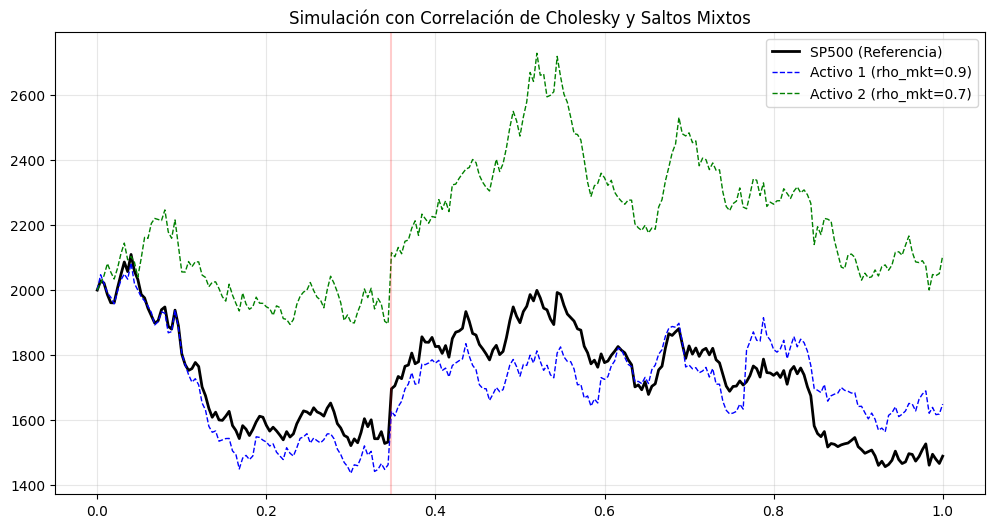

Matriz de Correlación SP500-Activo1: 0.8064


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulacion_cholesky_saltos(T, dt, S0, mu, sigma, lamb_sys, lamb_idio, alpha, x_m):
    steps = int(T / dt)

    # 1. Definición de la Matriz de Correlación (según imagen)
    # Orden: [0: SP500, 1: Activo_1, 2: Activo_2]
    rho = np.array([
        [1.0, 0.9, 0.7],
        [0.9, 1.0, 0.6],
        [0.7, 0.6, 1.0]
    ])

    # Descomposición de Cholesky: L tal que L * L^T = rho
    L = np.linalg.cholesky(rho)

    # 2. Generación de Difusión Correlacionada (eta_i)
    # Generamos 3 series de normales independientes
    Z = np.random.normal(0, 1, (3, steps))
    # Correlacionamos: epsilon = L * Z
    eta = L @ Z  # Matriz de 3 x steps

    # 3. Simulación de Saltos (Poisson + Pareto)
    # Salto Sistémico (afecta a los 3)
    dN_sys = np.random.poisson(lamb_sys * dt, steps)
    ind_sys = np.where(np.random.rand(steps) < 0.5, 1, -1)
    v_sys = (np.random.pareto(alpha, steps) + 1) * x_m
    jumps_sys = ind_sys * v_sys * dN_sys

    # Saltos Idiosincráticos (independientes para Activo 1 y 2)
    dN_idio = np.random.poisson(lamb_idio * dt, (2, steps))
    ind_idio = np.where(np.random.rand(2, steps) < 0.5, 1, -1)
    v_idio = (np.random.pareto(alpha, (2, steps)) + 1) * x_m
    jumps_idio = ind_idio * v_idio * dN_idio

    # 4. Construcción de Trayectorias (Vectorización por componente)
    drift = (mu - 0.5 * sigma**2) * dt

    # Retornos SP500 (Usa eta[0])
    r_mkt = drift + sigma * eta[0] * np.sqrt(dt) + jumps_sys

    # Retornos Activos (Usan eta[1], eta[2] + jumps_sys + jumps_idio)
    r_a1 = drift + sigma * eta[1] * np.sqrt(dt) + jumps_sys + jumps_idio[0]
    r_a2 = drift + sigma * eta[2] * np.sqrt(dt) + jumps_sys + jumps_idio[1]

    # Integración (Precios)
    paths = S0 * np.exp(np.column_stack([
        np.zeros(3),
        np.cumsum(np.vstack([r_mkt, r_a1, r_a2]), axis=1)
    ]))

    return paths, dN_sys

# --- Parámetros ---
params = {
    'T': 1.0, 'dt': 1/250, 'S0': 2000, 'mu': 0.05,
    'sigma': 0.25, 'lamb_sys': 2.0, 'lamb_idio': 4.0,
    'alpha': 2.2, 'x_m': 0.02
}

paths, dN_sys = simulacion_cholesky_saltos(**params)

# --- Gráfico de Verificación ---
t = np.linspace(0, params['T'], paths.shape[1])
plt.figure(figsize=(12, 6))
plt.plot(t, paths[0], 'k-', lw=2, label='SP500 (Referencia)')
plt.plot(t, paths[1], 'b--', lw=1, label='Activo 1 (rho_mkt=0.9)')
plt.plot(t, paths[2], 'g--', lw=1, label='Activo 2 (rho_mkt=0.7)')

# Marcar saltos sistémicos
for ts in t[1:][dN_sys > 0]:
    plt.axvline(ts, color='red', alpha=0.2)

plt.title("Simulación con Correlación de Cholesky y Saltos Mixtos")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Verificación de Correlación Empírica (Solo difusión, quitando saltos para validar Cholesky)
print(f"Matriz de Correlación SP500-Activo1: {np.corrcoef(paths[0], paths[1])[0,1]:.4f}")

--- REPORTE DE VALIDACIÓN ---
Saltos Sistémicos Esperados: 5.00
Saltos Sistémicos Promedio (Simulados): 5.11
Proporción de sims con al menos 1 salto sistémico: 99.40%
Error de propagación sistémica (debe ser ~0): 8.67e-19
Saltos Idiosincráticos Promedio por Activo: 2.00


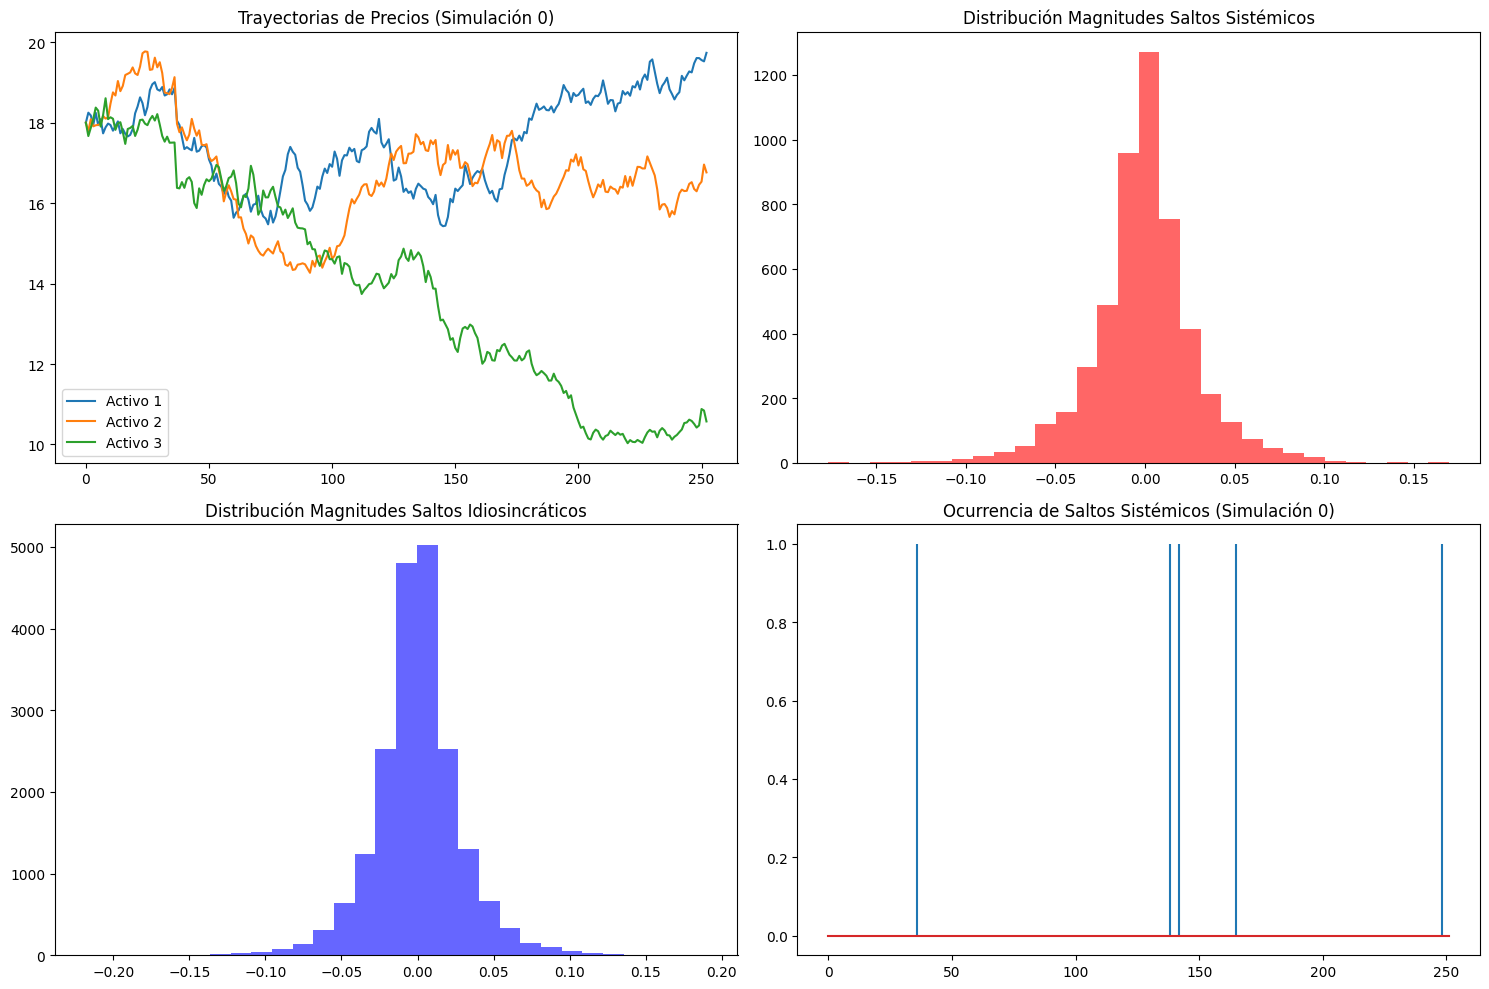

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import genpareto

# ==========================================
# 1. Parámetros Globales
# ==========================================
params = {
    "n_assets": 10,
    "n_steps": 252,
    "n_simulations": 1000,
    "dt": 1/252,
    "S0": 18,
    "r": 0.075,
    "sigma": 0.2,
    "lambda_systemic": 5,
    "lambda_idio": 2,
    "pareto_scale": 0.02,
    "pareto_shape": 0.00001,
    "prob_positive_jump": 0.5
}

def inverse_gen_pareto(u, shape, scale):
    """Transformada inversa de la Pareto Generalizada."""
    return (scale / shape) * (np.power(u, -shape) - 1)

# ==========================================
# 2. Generación de Saltos (Vectorizada)
# ==========================================
def generate_jumps(shape, scale, prob_pos, size):
    u = np.random.uniform(0, 1, size)
    magnitudes = inverse_gen_pareto(u, shape, scale)
    signs = np.where(np.random.uniform(0, 1, size) < prob_pos, 1, -1)
    return magnitudes * signs

# --- Saltos Sistémicos (Mercado) ---
p_sys = 1 - np.exp(-params["lambda_systemic"] * params["dt"])
market_jumped = np.random.uniform(0, 1, (params["n_steps"], params["n_simulations"])) < p_sys
sys_magnitudes_raw = generate_jumps(params["pareto_shape"], params["pareto_scale"],
                                    params["prob_positive_jump"], (params["n_steps"], params["n_simulations"]))
systemic_magnitudes = market_jumped * sys_magnitudes_raw

# --- Saltos Idiosincráticos (Activos) ---
p_idio = 1 - np.exp(-params["lambda_idio"] * params["dt"])
idio_jumped = np.random.uniform(0, 1, (params["n_assets"], params["n_steps"], params["n_simulations"])) < p_idio
idio_magnitudes_raw = generate_jumps(params["pareto_shape"], params["pareto_scale"],
                                     params["prob_positive_jump"], (params["n_assets"], params["n_steps"], params["n_simulations"]))
idio_magnitudes = idio_jumped * idio_magnitudes_raw

# ==========================================
# 3. Simulación de Trayectorias (Vectorizada)
# ==========================================
# Componente Difusivo: r*dt + sigma*sqrt(dt)*epsilon
epsilon = np.random.normal(0, 1, (params["n_assets"], params["n_steps"], params["n_simulations"]))
diff_return = params["r"] * params["dt"] + params["sigma"] * np.sqrt(params["dt"]) * epsilon

# Retorno total por paso: Difusión + Salto Sistémico (expandido) + Salto Idiosincrático
# systemic_magnitudes tiene forma (steps, sims), se expande a (assets, steps, sims)
total_return_steps = diff_return + systemic_magnitudes[np.newaxis, :, :] + idio_magnitudes

# Evolución del precio: S_t = S_{t-1} * (1 + return)
# Usamos cumprod para evitar el bucle for en el tiempo
price_ratios = 1 + total_return_steps
prices = np.zeros((params["n_assets"], params["n_steps"] + 1, params["n_simulations"]))
prices[:, 0, :] = params["S0"]
prices[:, 1:, :] = params["S0"] * np.cumprod(price_ratios, axis=1)

# ==========================================
# 4. Validación y Estadísticas
# ==========================================
# 4.1 Validación Sistémica
actual_sys_count = np.sum(market_jumped, axis=0)
prop_any_sys_jump = np.mean(actual_sys_count > 0)
expected_sys_jumps = params["lambda_systemic"] * (params["n_steps"] * params["dt"])

# 4.2 Validación Idiosincrática
actual_idio_count = np.sum(idio_jumped, axis=(0, 1)) / params["n_assets"]
expected_idio_jumps = params["lambda_idio"] * (params["n_steps"] * params["dt"])

# 4.3 Verificación de propagación: ¿Todos los activos saltan igual en salto sistémico?
# Tomamos un punto donde market_jumped es True
sample_t, sample_sim = np.where(market_jumped)
if len(sample_t) > 0:
    t_idx, sim_idx = sample_t[0], sample_sim[0]
    sys_val = systemic_magnitudes[t_idx, sim_idx]
    # Comprobar si el retorno de todos los activos en ese (t, sim) contiene sys_val
    # (Restando el componente difusivo e idiosincrático)
    check_val = total_return_steps[:, t_idx, sim_idx] - diff_return[:, t_idx, sim_idx] - idio_magnitudes[:, t_idx, sim_idx]
    propagation_error = np.max(np.abs(check_val - sys_val))
else:
    propagation_error = 0

# ==========================================
# 5. Reporte y Visualización
# ==========================================
print("--- REPORTE DE VALIDACIÓN ---")
print(f"Saltos Sistémicos Esperados: {expected_sys_jumps:.2f}")
print(f"Saltos Sistémicos Promedio (Simulados): {np.mean(actual_sys_count):.2f}")
print(f"Proporción de sims con al menos 1 salto sistémico: {prop_any_sys_jump:.2%}")
print(f"Error de propagación sistémica (debe ser ~0): {propagation_error:.2e}")
print(f"Saltos Idiosincráticos Promedio por Activo: {np.mean(actual_idio_count):.2f}")

# Gráficos
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# 1. Trayectorias (1ra Simulación, 3 activos)
for i in range(3):
    axs[0, 0].plot(prices[i, :, 0], label=f"Activo {i+1}")
axs[0, 0].set_title("Trayectorias de Precios (Simulación 0)")
axs[0, 0].legend()

# 2. Histograma Magnitudes Sistémicas
axs[0, 1].hist(systemic_magnitudes[market_jumped].flatten(), bins=30, color='red', alpha=0.6)
axs[0, 1].set_title("Distribución Magnitudes Saltos Sistémicos")

# 3. Histograma Magnitudes Idiosincráticas
axs[1, 0].hist(idio_magnitudes[idio_jumped].flatten(), bins=30, color='blue', alpha=0.6)
axs[1, 0].set_title("Distribución Magnitudes Saltos Idiosincráticos")

# 4. Ocurrencia de saltos sistémicos (Time Series)
axs[1, 1].stem(np.arange(params["n_steps"]), market_jumped[:, 0], markerfmt=' ')
axs[1, 1].set_title("Ocurrencia de Saltos Sistémicos (Simulación 0)")

plt.tight_layout()
plt.show()

# Guardar resumen
summary_df = pd.DataFrame({
    "Simulacion_ID": np.arange(params["n_simulations"]),
    "Num_Saltos_Sistemicos": actual_sys_count,
    "Promedio_Saltos_Idio": actual_idio_count,
    "Precio_Final_Promedio": np.mean(prices[:, -1, :], axis=0)
})
summary_df.to_csv("resultado_simulacion.csv", index=False)

--- Análisis de Riesgo del Portafolio ---
VaR (95%): 34.8419%
cVaR (95%): 41.2551%


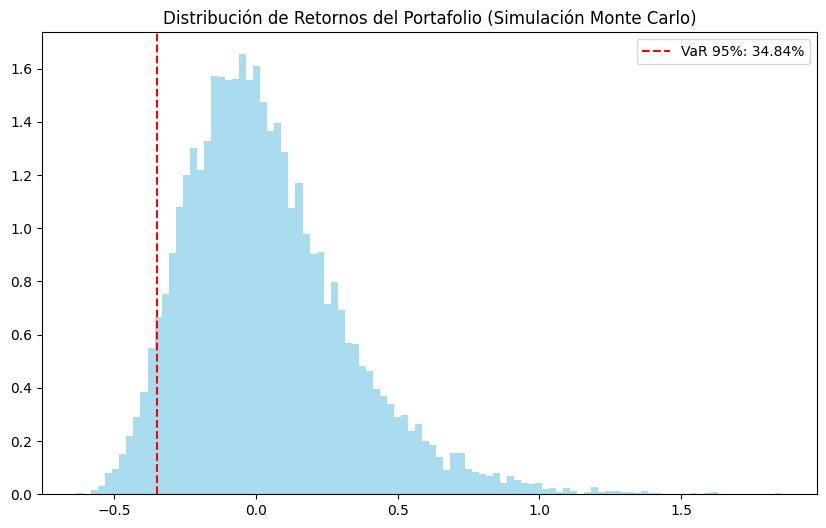

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genpareto

# ==========================================
# 1. VALORES INICIALES (Configurables)
# ==========================================
# Precios Iniciales
SP500_0 = 2000
S1_0 = 1000
S2_0 = 1500

# Parámetros de Mercado
dt = 1/250
r = 0.035
n_steps = 250
n_sims = 10000

# Volatilidades
sigma_SP500 = 0.25
sigma_S1 = 0.1
sigma_S2 = 0.4

# Parámetros de Salto (Poisson-Pareto)
lambda_mdo = 14  # Intensidad sistémica
lambda_idio = 4  # Intensidad idiosincrática (ejemplo)
xi_pareto = 0.00001
sigma_pareto = 0.02
mu_pareto = 0  # Localización

# Matriz de Correlación
rho = np.array([
    [1.0, 0.9, 0.7],  # SP500
    [0.9, 1.0, 0.6],  # S1
    [0.7, 0.6, 1.0]   # S2
])

# ==========================================
# 2. PROCESAMIENTO ESTOCÁSTICO (Vectorizado)
# ==========================================

# A. Descomposición de Cholesky para η correlacionados
L = np.linalg.cholesky(rho)

# B. Generación de Ruido Gaussiano Correlacionado
# Z: (3 activos, steps, sims)
z_indep = np.random.normal(0, 1, (3, n_steps, n_sims))
eta = np.einsum('ij,jks->iks', L, z_indep)

# C. Generación de Saltos (Pareto con Signo Aleatorio)
def get_pareto_jumps(size):
    # Usando la función de cuantiles (Transformada Inversa)
    u = np.random.uniform(0, 1, size)
    # Magnitud (Pareto Generalizada)
    nu = genpareto.ppf(u, c=xi_pareto, loc=mu_pareto, scale=sigma_pareto)
    # Indicadora de signo (1 si > 0.5 -> positivo, else negativo)
    indicator = np.where(np.random.uniform(0, 1, size) < 0.5, 1, -1)
    return nu * indicator

# D. Ocurrencia de Saltos (Proceso de Poisson)
prob_sys = 1 - np.exp(-lambda_mdo * dt)
dN_t_sys = np.random.uniform(0, 1, (n_steps, n_sims)) < prob_sys
nu_sys = get_pareto_jumps((n_steps, n_sims)) * dN_t_sys

# E. Saltos Idiosincráticos (Para Activos 1 y 2)
prob_idio = 1 - np.exp(-lambda_idio * dt)
dN_t_idio = np.random.uniform(0, 1, (2, n_steps, n_sims)) < prob_idio
nu_idio = get_pareto_jumps((2, n_steps, n_sims)) * dN_t_idio

# ==========================================
# 3. CÁLCULO DE DIFERENCIALES Y PRECIOS
# ==========================================

# Matrices para almacenar retornos (3, steps, sims)
dSi_Si = np.zeros((3, n_steps, n_sims))

# Ecuación Mercado: dSP500 = (r*dt + sigma*eta1*sqrt(dt) + nu_sys)
dSi_Si[0] = (r * dt) + (sigma_SP500 * eta[0] * np.sqrt(dt)) + nu_sys

# Ecuación Activos: dSi = (r*dt + sigma*eta*sqrt(dt) + nu_sys + nu_idio)
for i in range(1, 3):
    dSi_Si[i] = (r * dt) + (globals()[f'sigma_S{i}'] * eta[i] * np.sqrt(dt)) + \
                nu_sys + nu_idio[i-1]

# Simulación de Precios: S_t = S_0 * product(1 + dS/S)
prices = np.zeros((3, n_steps + 1, n_sims))
prices[0, 0, :] = SP500_0
prices[1, 0, :] = S1_0
prices[2, 0, :] = S2_0

for i in range(3):
    prices[i, 1:, :] = prices[i, 0, 0] * np.cumprod(1 + dSi_Si[i], axis=0)

# ==========================================
# 4. VaR y cVaR DEL PORTAFOLIO
# ==========================================
# Suponiendo pesos iguales (1/3 cada uno)
portafolio_final = (prices[0, -1, :] + prices[1, -1, :] + prices[2, -1, :]) / 3
precios_iniciales = (SP500_0 + S1_0 + S2_0) / 3
retornos_port = (portafolio_final / precios_iniciales) - 1

alpha_95 = 0.05
alpha_99 = 0.01

VaR_95 = -np.percentile(retornos_port, alpha_95 * 100)
cVaR_95 = -retornos_port[retornos_port <= -VaR_95].mean()

# ==========================================
# 5. RESULTADOS
# ==========================================
print(f"--- Análisis de Riesgo del Portafolio ---")
print(f"VaR (95%): {VaR_95:.4%}")
print(f"cVaR (95%): {cVaR_95:.4%}")

# Gráfica de resultados
plt.figure(figsize=(10, 6))
plt.hist(retornos_port, bins=100, color='skyblue', alpha=0.7, density=True)
plt.axvline(-VaR_95, color='red', linestyle='--', label=f'VaR 95%: {VaR_95:.2%}')
plt.title("Distribución de Retornos del Portafolio (Simulación Monte Carlo)")
plt.legend()
plt.show()

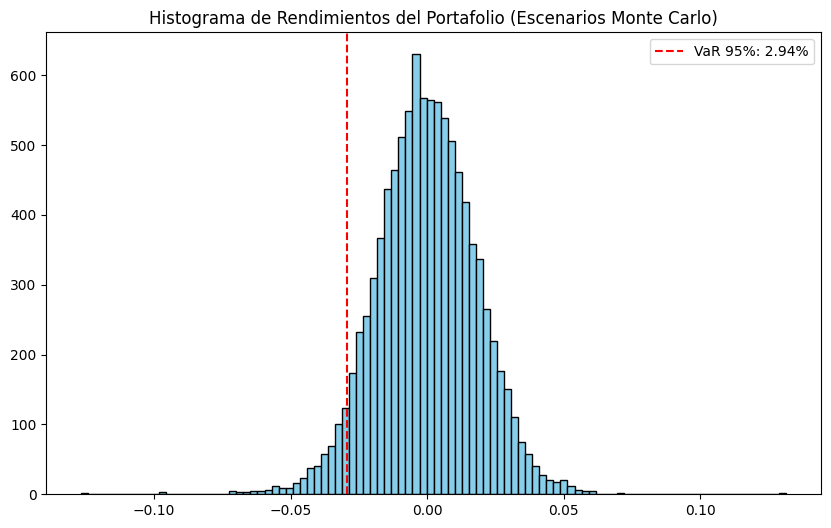

VaR (95%): 2.9388%
cVaR (95%): 3.9734%


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genpareto

# ==========================================
# 1. VALORES INICIALES [cite: 2]
# ==========================================
SP500_0 = 2000    # [cite: 3]
S1_0 = 20         # [cite: 9]
S2_0 = 100        # [cite: 10]
dt = 1/250        # [cite: 4]
r = 0.035         # [cite: 8]
n = 10000         # [cite: 11]

sigma_SP500 = 0.25 # [cite: 5]
sigma_S1 = 0.1     # [cite: 6]
sigma_S2 = 0.4     # [cite: 7]

w1, w2, w3 = 0.4, 0.55, 0.05 # Pesos: S1, S2, SP500 [cite: 12, 13, 14]

# Parámetros Pareto [cite: 22, 23, 24]
xi_p, sigma_p, mu_p = 0.00001, 0.02, 0

# Intensidades Poisson [cite: 20, 34, 41]
lambda_mdo = 14
lambda_idio = 9

# ==========================================
# 2. GENERACIÓN Y EXPORTACIÓN DE VARIABLES
# ==========================================

# A. Normales Z e Eta (Cholesky) [cite: 47]
Z = np.random.normal(0, 1, (n, 3))
pd.DataFrame(Z).to_csv("Z_matrix.csv", index=False)

rho = np.array([[1.0, 0.9, 0.7], [0.9, 1.0, 0.6], [0.7, 0.6, 1.0]]) # [cite: 27]
L = np.linalg.cholesky(rho)
Eta = Z @ L.T
pd.DataFrame(Eta).to_csv("Eta_matrix.csv", index=False)

# B. Procesos de Poisson (Poi) [cite: 48]
# Si hay salto en mercado (Poi[0]), se activa en todos [cite: 18]
p_sys = 1 - np.exp(-lambda_mdo * dt)
p_idio = 1 - np.exp(-lambda_idio * dt)

market_jump_occured = np.random.rand(n) < p_sys
Poi = np.zeros((n, 3))
Poi[:, 0] = market_jump_occured
Poi[:, 1] = np.random.rand(n) < p_idio
Poi[:, 2] = np.random.rand(n) < p_idio
pd.DataFrame(Poi.astype(int)).to_csv("Poi_matrix.csv", index=False)

# C. Variables de Pareto (Par) [cite: 49]
def get_pareto(size):
    u = np.random.uniform(0, 1, size)
    mag = (sigma_p / xi_p) * (np.power(u, -xi_p) - 1)
    sign = np.where(np.random.rand(size) < 0.5, 1, -1) # [cite: 19]
    return mag * sign

Par = np.column_stack([get_pareto(n) for _ in range(3)])
pd.DataFrame(Par).to_csv("Par_matrix.csv", index=False)

# ==========================================
# 3. ESCENARIOS Y ACTUALIZACIÓN [cite: 50, 51]
# ==========================================

# Diferenciales (dS) - Notación vectorizada
dSP500 = (r*dt + sigma_SP500*Eta[:, 0]*np.sqrt(dt) + Par[:, 0]*Poi[:, 0]) * SP500_0 # [cite: 16]
dS1 = (r*dt + sigma_S1*Eta[:, 1]*np.sqrt(dt) + Par[:, 0]*Poi[:, 0] + Par[:, 1]*Poi[:, 1]) * S1_0 # [cite: 30]
dS2 = (r*dt + sigma_S2*Eta[:, 2]*np.sqrt(dt) + Par[:, 0]*Poi[:, 0] + Par[:, 2]*Poi[:, 2]) * S2_0 # [cite: 30]

cambios = pd.DataFrame({"dSP500": dSP500, "dS1": dS1, "dS2": dS2})
cambios.to_csv("cambios_activos.csv", index=False)

# Precios Finales (S1) [cite: 46, 51]
SP500_1 = SP500_0 + dSP500
S1_1 = S1_0 + dS1
S2_1 = S2_0 + dS2

# ==========================================
# 4. PORTAFOLIO Y RIESGO [cite: 52, 53, 54]
# ==========================================
Pi0 = w1*S1_0 + w2*S2_0 + w3*SP500_0 # [cite: 52]
Pi1 = w1*S1_1 + w2*S2_1 + w3*SP500_1 # [cite: 53]
pd.DataFrame({"Pi1": Pi1}).to_csv("Pi1_final.csv", index=False)

r_Pi = (Pi1 / Pi0) - 1 # [cite: 54]
pd.DataFrame({"Rendimiento": r_Pi}).to_csv("rendimiento_portafolio.csv", index=False)

# VaR y cVaR
alpha = 0.05
VaR = -np.percentile(r_Pi, alpha * 100)
cVaR = -r_Pi[r_Pi <= -VaR].mean()

# ==========================================
# 5. VISUALIZACIÓN [cite: 56]
# ==========================================
plt.figure(figsize=(10, 6))
plt.hist(r_Pi, bins=100, color='skyblue', edgecolor='black')
plt.axvline(-VaR, color='red', linestyle='dashed', label=f'VaR 95%: {VaR:.2%}')
plt.title("Histograma de Rendimientos del Portafolio (Escenarios Monte Carlo)")
plt.legend()
plt.show()

print(f"VaR (95%): {VaR:.4%}")
print(f"cVaR (95%): {cVaR:.4%}")